# This notebook shows how to fit a linear resonator in the reflection configuration.

In [1]:
from __future__ import division, absolute_import, print_function
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

from resonator import background, reflection, see

Create data using the model plus gaussian noise. The model is the product of the reflection resonator model and a background model, which in this case assumes that the magnitude is independent of frequency and that the phase is described by an offset and an electrical delay, which adds a phase that is linearly dependent on frequency.

In [2]:
import pandas as pd
import numpy as np

# df = pd.read_csv("/Users/b3-34/Projects/uni/bakalaurinis/matavimai/droplet_csv/1.csv", skiprows=2)
df = pd.read_csv("/Users/b3-34/Projects/uni/bakalaurinis/matavimai/droplet_csv/2.csv", skiprows=2)
# df = pd.read_csv("/Users/b3-34/Projects/uni/bakalaurinis/matavimai/droplet_csv/3.csv", skiprows=2)
# df = pd.read_csv("/Users/b3-34/Projects/uni/bakalaurinis/matavimai/droplet_csv/4.csv", skiprows=2)
# df = pd.read_csv("/Users/b3-34/Projects/uni/bakalaurinis/matavimai/droplet_csv/5.csv", skiprows=2)
# df = pd.read_csv("/Users/b3-34/Projects/uni/bakalaurinis/matavimai/droplet_csv/6.csv", skiprows=2)

df.columns = ['frequency', 'S21_db', 'S21_deg']
df['S21'] = np.float_power(10, df['S21_db'].to_numpy()/20)

# Filter frequencies around mode

# freq_min = 10.02e9    # droplet 1
# freq_max = 10.07e9
freq_min = 9.2e9    # droplet 2
freq_max = 9.23e9
# freq_min = 9.465e9  # droplet 3
# freq_max = 9.525e9
# freq_min = 9.15e9   # droplet 4
# freq_max = 9.2e9
# freq_min = 9.19e9   # droplet 5
# freq_max = 9.225e9
# freq_min = 9.42e9   # droplet 6
# freq_max = 9.46e9

df = df[(df['frequency'] >= freq_min) & (df['frequency'] <= freq_max)]

data = df['S21'].to_numpy() * np.exp(1j * np.deg2rad(df["S21_deg"])).to_numpy()
frequency = df["frequency"].to_numpy()
print(df.head())

         frequency    S21_db    S21_deg       S21
2000  9.200025e+09 -5.097208  47.777685  0.556083
2001  9.200075e+09 -5.091913  47.579316  0.556422
2002  9.200125e+09 -5.090194  47.372822  0.556532
2003  9.200175e+09 -5.091963  47.160337  0.556419
2004  9.200225e+09 -5.094405  46.949871  0.556262


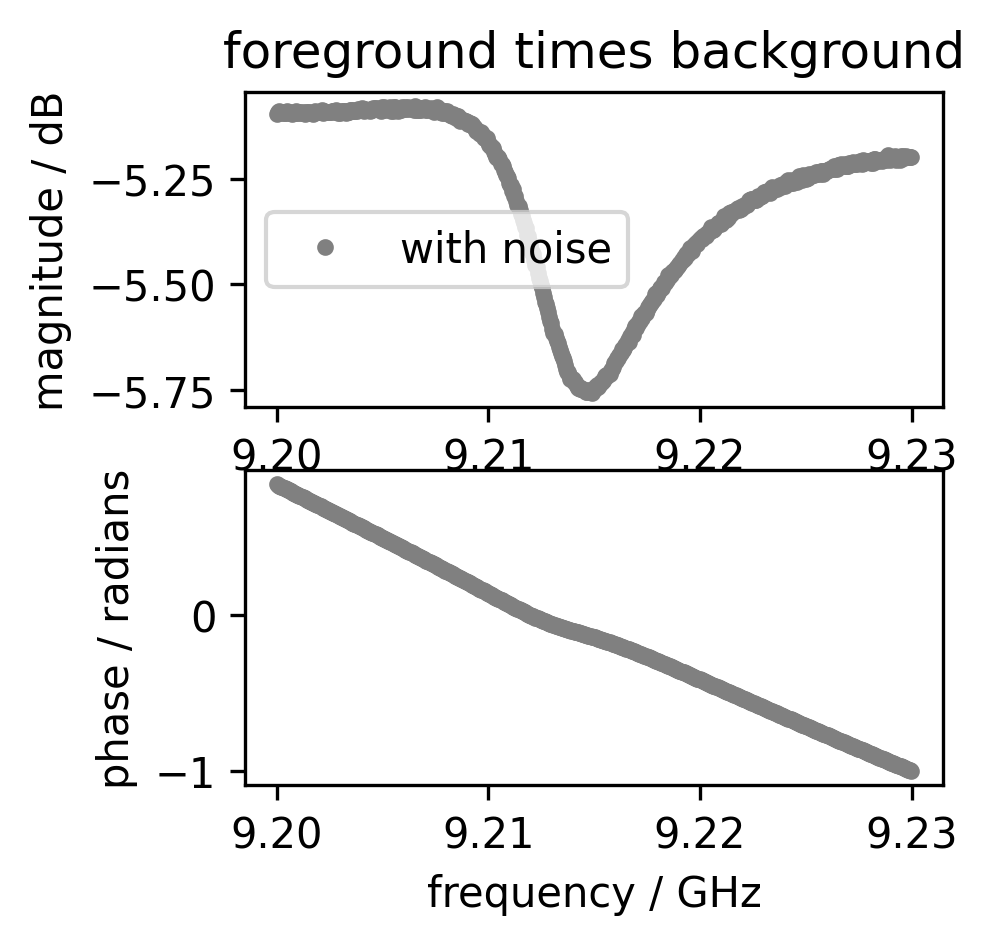

In [3]:
fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(3, 3), dpi=300)

ax_mag.set_ylabel('magnitude / dB')
ax_mag.plot(1e-9 * frequency, 20 * np.log10(np.abs(data)), '.', color='gray', label='with noise')
ax_mag.set_title('foreground times background')
ax_mag.legend()

ax_phase.set_xlabel('frequency / GHz')
ax_phase.set_ylabel('phase / radians')
ax_phase.plot(1e-9 * frequency, np.angle(data), '.', color='gray', label='with noise')


## Fit the model to the data using a LinearReflectionFitter.

If no errors are given, the fitting assumes equal errors for each point and thus equal weights, so errors are not generally necessary unless they vary between points.

In [4]:
import lmfit

params = lmfit.Parameters()
params = lmfit.Parameters()
params.add(name='internal_loss', value=1e-9) 
resonator = reflection.LinearReflectionFitter(frequency=frequency, data=data, params=params, background_model=background.MagnitudePhaseDelay())
print(resonator.result.fit_report())  # result is a lmfit.model.ModelResult object

[[Model]]
    (Model(magnitude_phase_delay) * Model(linear_reflection))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 193
    # data points      = 1200
    # variables        = 6
    chi-square         = 0.06998793
    reduced chi-square = 5.8616e-05
    Akaike info crit   = -11687.4111
    Bayesian info crit = -11656.8707
    R-squared          = np.complex128(17604480026346.613+2042504130184.3948j)
[[Variables]]
    frequency_reference:  9.215004e+09 (fixed)
    magnitude:            0.56755598 +/- 0.00112326 (0.20%) (init = 0.5188149)
    phase:                3.02358287 +/- 6.1784e-04 (0.02%) (init = 2.99045)
    delay:               -1.0143e-08 +/- 2.1356e-11 (0.21%) (init = -8.784996e-09)
    resonance_frequency:  9.2170e+09 +/- 75212.8268 (0.00%) (init = 9.211653e+09)
    coupling_loss:        6.0264e-05 +/- 3.3072e-06 (5.49%) (init = 0.001391249)
    internal_loss:        0.00134304 +/- 5.2963e-05 (3.94%) (init = 1e-09)
[[Correlations]] (unreporte

## Plot the data

Use the `see.py` fitting module to plot the data, model, and resonance. These functions create a new figure and axes by default, but can also be used to plot data on existing axes, as shown below.

Note that the normalized (resonator plane) data forms a circle in the complex plane even though the raw data has a more complicated shape due to the background.

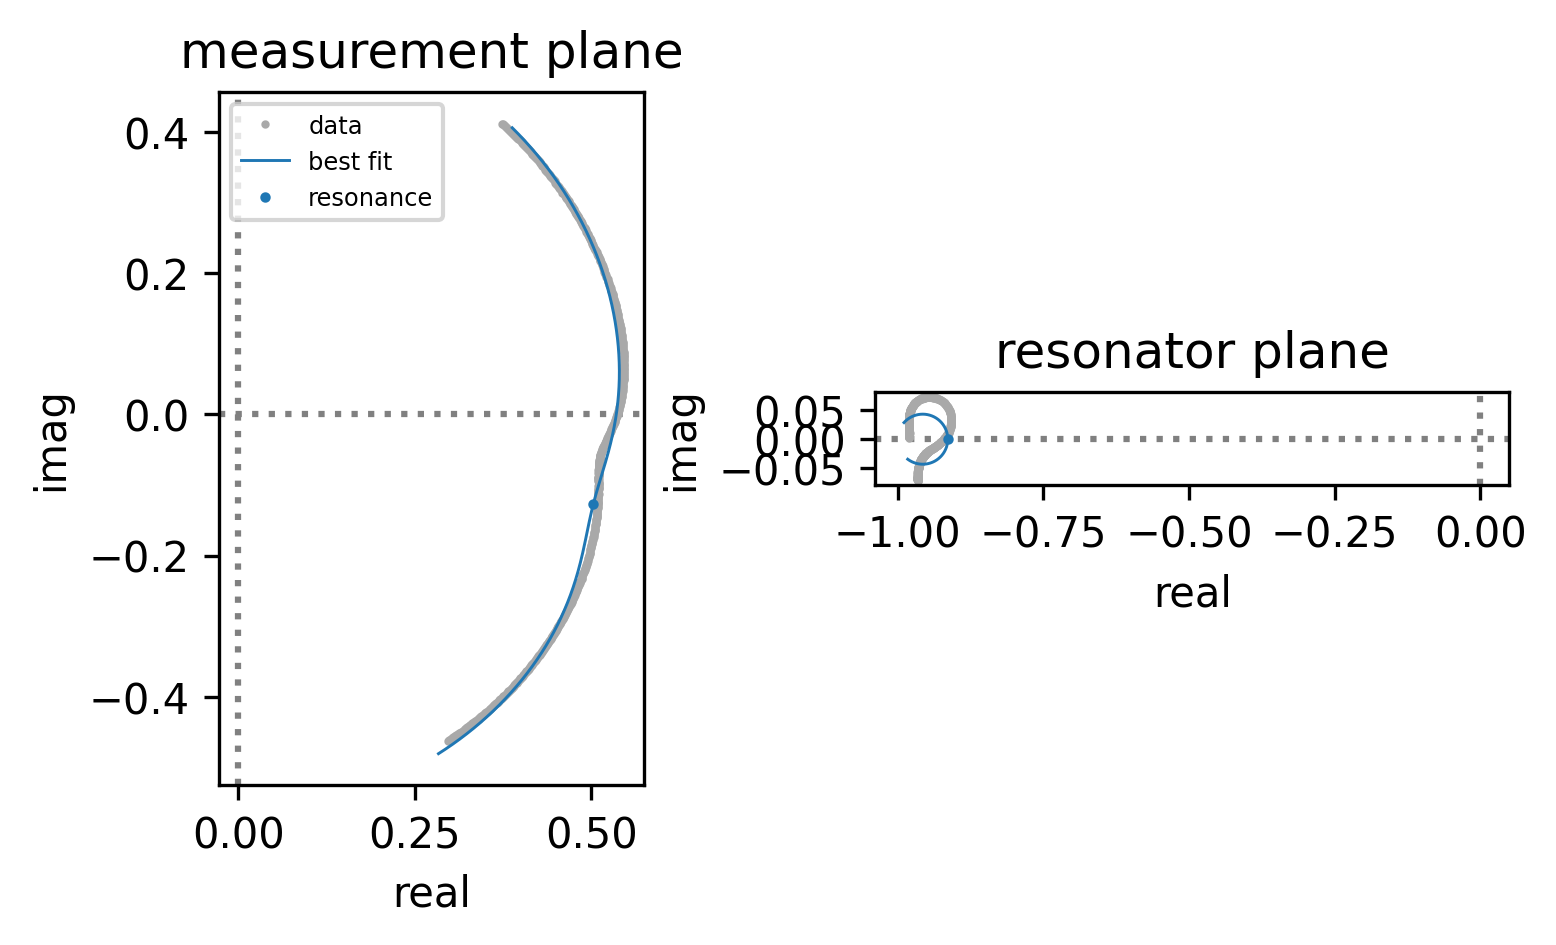

In [5]:
fig, (ax_raw, ax_norm) = plt.subplots(1, 2, figsize=(6, 3), dpi=300)  # Adjust these values for your plot settings
ax_raw.set_title('measurement plane')
ax_norm.set_title('resonator plane')
see.real_and_imaginary(resonator=resonator, axes=ax_raw, normalize=False)
see.real_and_imaginary(resonator=resonator, axes=ax_norm, normalize=True)
ax_raw.legend(fontsize='xx-small');

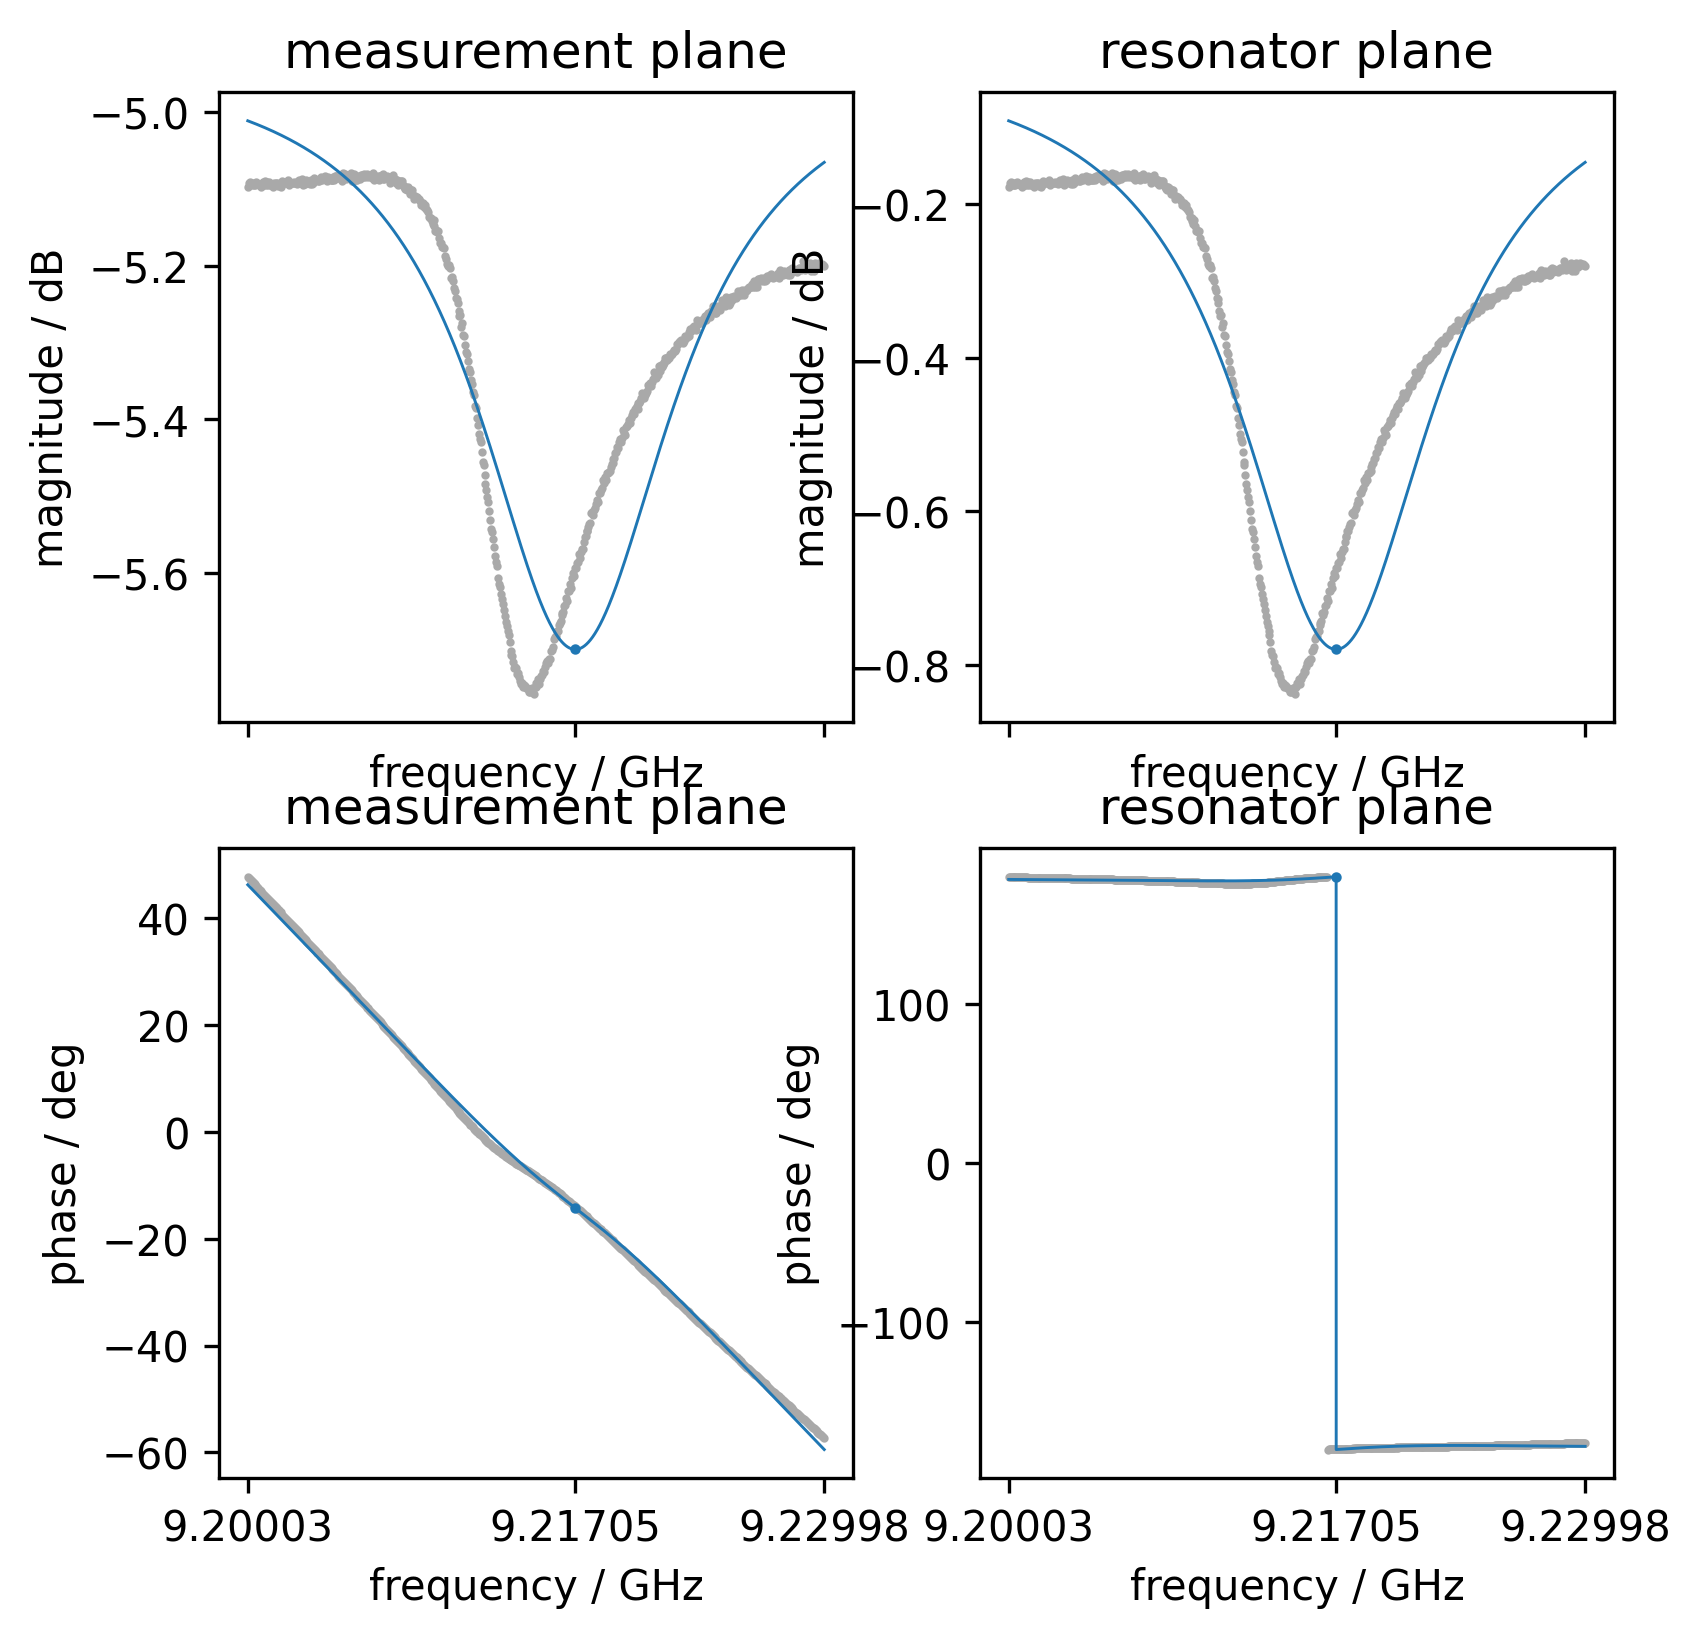

In [6]:
fig, axes = plt.subplots(2, 2, sharex='all', figsize=(6, 6), dpi=300)  # Adjust these values for your plot settings
ax_raw_mag, ax_norm_mag, ax_raw_phase, ax_norm_phase = axes.flatten()
ax_raw_mag.set_title('measurement plane')
ax_norm_mag.set_title('resonator plane')
ax_raw_phase.set_title('measurement plane')
ax_norm_phase.set_title('resonator plane')
see.magnitude_vs_frequency(resonator=resonator, axes=ax_raw_mag, normalize=False, frequency_scale=1e-9)
see.magnitude_vs_frequency(resonator=resonator, axes=ax_norm_mag, normalize=True, frequency_scale=1e-9)
see.phase_vs_frequency(resonator=resonator, axes=ax_raw_phase, normalize=False, frequency_scale=1e-9)
see.phase_vs_frequency(resonator=resonator, axes=ax_norm_phase, normalize=True, frequency_scale=1e-9);

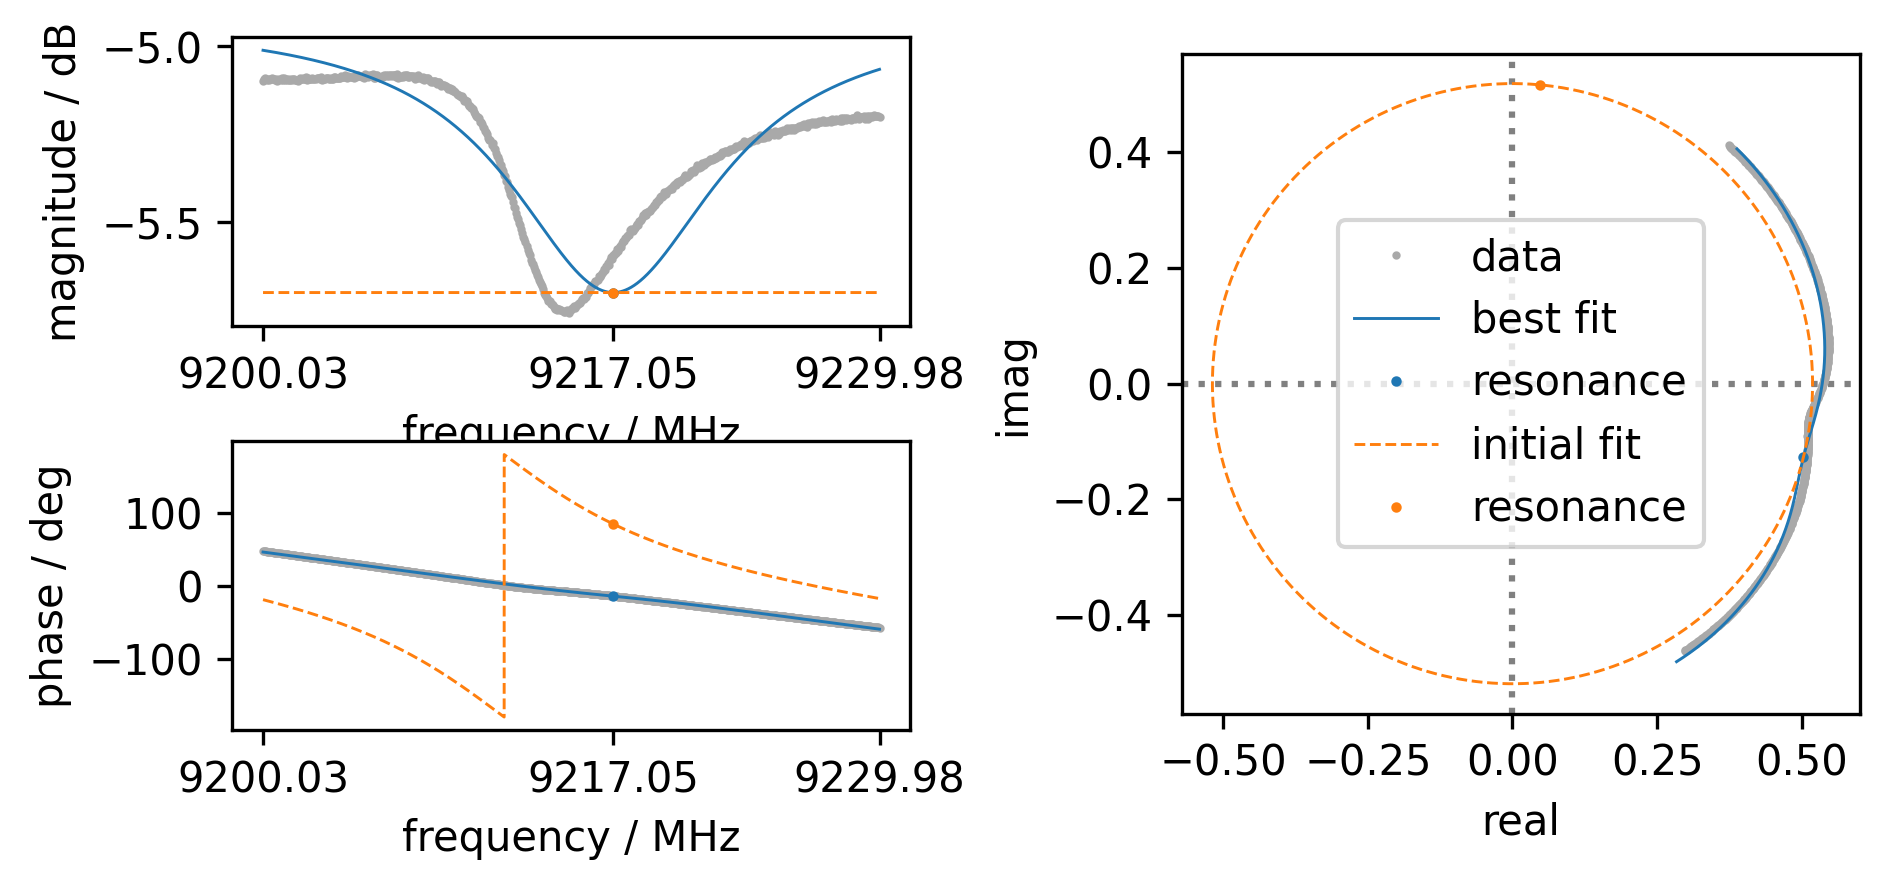

In [7]:
fig, (ax_magnitude, ax_phase, ax_complex) = see.triptych(resonator=resonator, plot_initial=True, frequency_scale=1e-6, figure_settings={'figsize': (7, 3), 'dpi': 300})
ax_complex.legend();